In [ ]:

import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd
# Set the path to the file you'd like to load
file_path = "synthetic_eeg_data-v3.csv"

# Load the latest version
df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "eyppler/disorders-and-diagnosis-eeg-dataset-v3",
  file_path)

print("A brief description of the data:", df.describe())
print("The first 5 rows: ",df.head())

100%|██████████| 556M/556M [00:15<00:00, 37.3MB/s]


A brief description of the data:                no.          age           IQ           EQ
count  3444.000000  3444.000000  3444.000000  3444.000000
mean   1722.500000    51.995935   114.256388   104.948316
std     994.341491    19.802129    15.823531    32.047275
min       1.000000    18.000000    87.000000    50.000000
25%     861.750000    35.000000   101.000000    77.000000
50%    1722.500000    52.000000   115.000000   105.000000
75%    2583.250000    70.000000   128.000000   133.000000
max    3444.000000    85.000000   141.000000   160.000000
The first 5 rows:     no. sex  age    eeg.date    education   IQ   EQ   disorder/diagnosis  \
0    1   F   28  2024-10-31  High School  124   99            Parkinson   
1    2   F   18  2024-06-07   University   98  108  Depressive disorder   
2    3   M   59  2024-06-23  High School  123  157     Bipolar disorder   
3    4   F   19  2024-06-20  High School   93  116          Psychopathy   
4    5   F   29  2025-01-03   University  101   51 

In [ ]:
#Preprocessing
df.isnull().sum()
df_clean = df.dropna() #the dataset initially lacks empty fields



In [ ]:
from sklearn.preprocessing import LabelEncoder
le_sex = LabelEncoder()
df['sex'] = le_sex.fit_transform(df['sex']) # Pass a 1D array (Sex)
le_disorder = LabelEncoder()
df['disorder/diagnosis'] = le_disorder.fit_transform(df['disorder/diagnosis']) # Pass a 1D array (Diagnosis)
le_education = LabelEncoder() # Add LabelEncoder for 'education'
df['education'] = le_education.fit_transform(df['education']) # Added: Encode 'education' column

In [ ]:
import ast
from sklearn.preprocessing import StandardScaler

# Original numerical scalar features
numerical_scalar_features = ['age', 'IQ', 'EQ']

# EEG electrode column names (original list columns)
eeg_cols = [f'EEG_Electrode_{i}' for i in range(1, 33)]

# 1. Convert string representations of lists to actual lists for EEG_Electrode columns
#    Using ast.literal_eval for safe evaluation of string literals
for col in eeg_cols:
    df[col] = df[col].apply(ast.literal_eval)

# 2. Determine the length of the EEG electrode lists (assuming all are consistent)
#    This is done by taking the first element of the first EEG column after conversion
list_length = len(df[eeg_cols[0]].iloc[0])

# 3. Create a list of new column names for the expanded EEG features
new_eeg_feature_names = [f"{eeg_col}_{j}" for eeg_col in eeg_cols for j in range(list_length)]

# 4. Create a temporary DataFrame for the expanded EEG features
#    This converts each list in an EEG column into multiple new columns
eeg_expanded_df_parts = []
for col in eeg_cols:
    eeg_expanded_df_parts.append(df[col].apply(pd.Series).add_prefix(f"{col}_"))

df_eeg_expanded = pd.concat(eeg_expanded_df_parts, axis=1)

# 5. Drop the original EEG columns from df
df = df.drop(columns=eeg_cols)

# 6. Concatenate the expanded EEG features back into df
df = pd.concat([df, df_eeg_expanded], axis=1)

# 7. Now, define the complete list of features to scale, including the newly expanded EEG features
all_features_to_scale = numerical_scalar_features + new_eeg_feature_names

# 8. Apply StandardScaler to the selected features in the modified df
scaler = StandardScaler()
df[all_features_to_scale] = scaler.fit_transform(df[all_features_to_scale])

*We're dividing the dataset in trial and testing data respectively*

In [ ]:


from sklearn.model_selection import train_test_split
remove = ['disorder/diagnosis','no.','eeg.date']
X = df.drop(remove,axis=1)
y = df['disorder/diagnosis']

X_train,X_val,y_train,y_val = train_test_split(
     X,y,test_size=0.2,random_state=42, stratify=y #to ensure that the proportion of data distributed across y has the same proportion
 )



*To build a flat multi class classifier using random forests module. A flat multiclass classifier is anything that classifies the entity NOT on a heirarchial basis.*

In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC #for robustness against outliers
from sklearn.neural_network import MLPClassifier
#random forest
rf_model=RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train,y_train)
#support vector machine
svm_model =SVC(kernel='rbf',random_state=42)
svm_model.fit(X_train,y_train)
#neural network
nn_model=MLPClassifier(hidden_layer_sizes=(128,64),random_state=42)
nn_model.fit(X_train,y_train)

MLPClassifier(hidden_layer_sizes=(128, 64), random_state=42)

*The following code boxes are here for the evaluation of the performance of various models. *

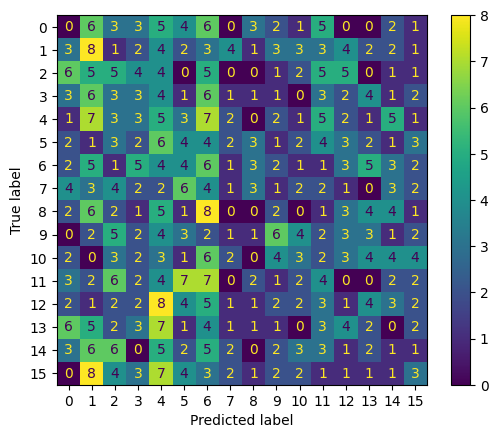

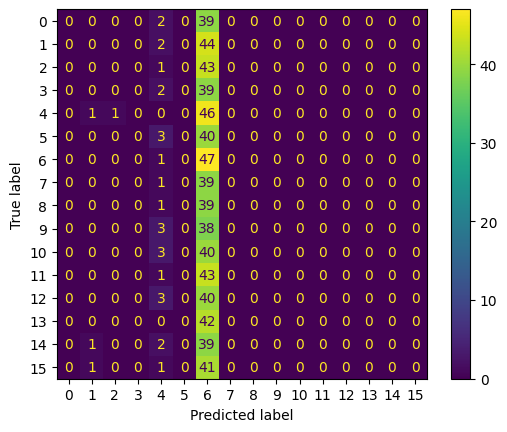

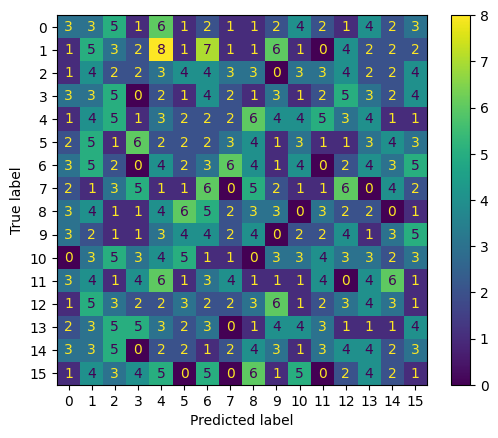

In [12]:
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
import matplotlib.pyplot as plt
predict = [rf_model.predict(X_val), svm_model.predict(X_val), nn_model.predict(X_val)]
for y_pred_model in predict:
  y_pred = y_pred_model
  cm = confusion_matrix(y_val,y_pred)
  disp = ConfusionMatrixDisplay(confusion_matrix=cm)
  disp.plot()
  plt.show()

The confusion matrices are depicted above. The next code details key matrices on the predictions made.

In [13]:
from sklearn.metrics import classification_report,accuracy_score,f1_score
for y_pred_model in predict:
  accuracy = accuracy_score(y_val,y_pred_model)
  print(f'accuracy: {accuracy}')
  f1 = f1_score(y_val,y_pred_model,average='weighted')
  print(f'f1 score: {f1}')
  print(classification_report(y_val,y_pred_model))


accuracy: 0.07547169811320754
f1 score: 0.07177297471276593
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        41
           1       0.11      0.17      0.14        46
           2       0.09      0.11      0.10        44
           3       0.08      0.07      0.07        41
           4       0.06      0.10      0.08        48
           5       0.09      0.09      0.09        43
           6       0.07      0.12      0.09        48
           7       0.05      0.03      0.03        40
           8       0.00      0.00      0.00        40
           9       0.18      0.15      0.16        41
          10       0.11      0.07      0.08        43
          11       0.09      0.09      0.09        44
          12       0.03      0.02      0.03        43
          13       0.06      0.05      0.05        42
          14       0.03      0.02      0.03        42
          15       0.10      0.07      0.08        43

    accuracy        

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


*We'll be visualizing our output using matplotlib, and seaborn.*

*To compare the model performance, ensure to look at the charts as structured below.*

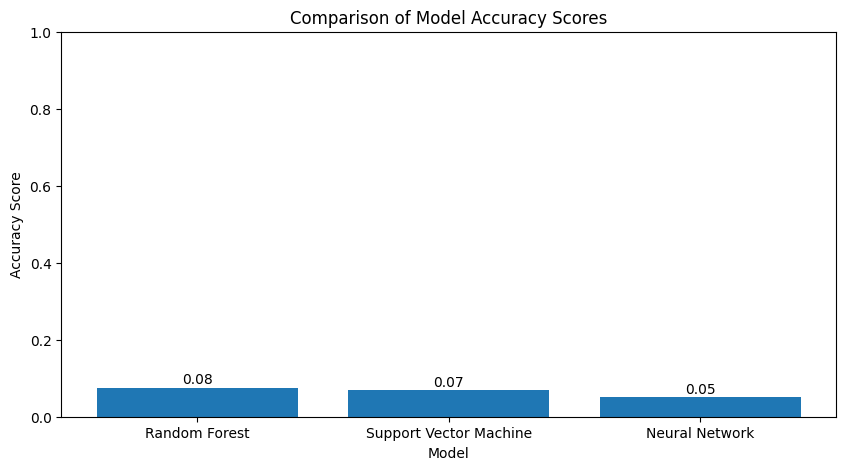

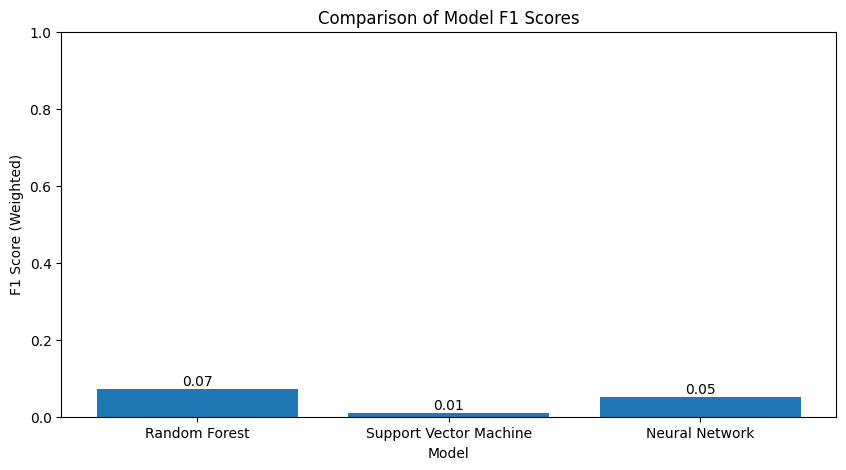

In [32]:
import matplotlib.pyplot as plt # Ensure plt is imported

models=['Random Forest','Support Vector Machine','Neural Network']
accuracy_scores = []
f1_scores = []

# Collect scores for each model
for y_pred_model in predict:
  accuracy_scores.append(accuracy_score(y_val,y_pred_model))
  f1_scores.append(f1_score(y_val,y_pred_model,average='weighted'))

# Plotting Accuracy for each model
plt.figure(figsize=(10, 5))
plt.bar(models, accuracy_scores)
plt.xlabel('Model')
plt.ylabel('Accuracy Score')
plt.title('Comparison of Model Accuracy Scores')
plt.ylim(0, 1)
for i, score in enumerate(accuracy_scores):
    plt.text(i, score + 0.01, f'{score:.2f}', ha='center')
plt.show()

# Plotting F1 Score for each model
plt.figure(figsize=(10, 5))
plt.bar(models, f1_scores)
plt.xlabel('Model')
plt.ylabel('F1 Score (Weighted)')
plt.title('Comparison of Model F1 Scores')
plt.ylim(0, 1)
for i, score in enumerate(f1_scores):
    plt.text(i, score + 0.01, f'{score:.2f}', ha='center')
plt.show()